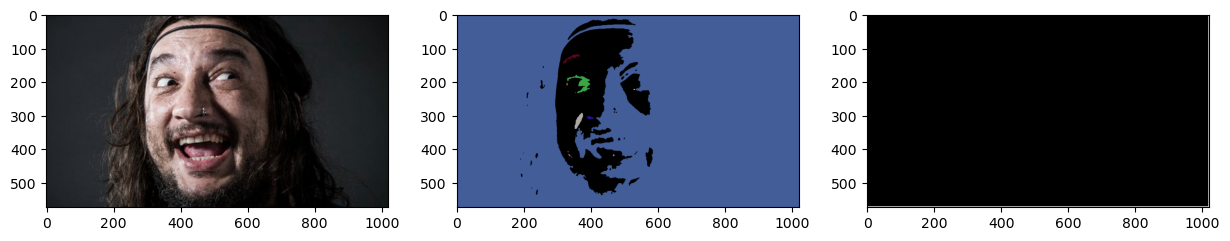

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('bananero.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# combino tecnicas
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# encontramos las regiones
num_l, label = cv2.connectedComponents(binary)

# identificamos por colores
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)

# fondo negro
color[0] = [0, 0, 0]
colorear = color[label]

# encontrar fronteras
contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(132)
plt.imshow(colorear)

plt.subplot(133)
plt.imshow(contorno_fin, cmap='gray')

plt.show()

CONTEO

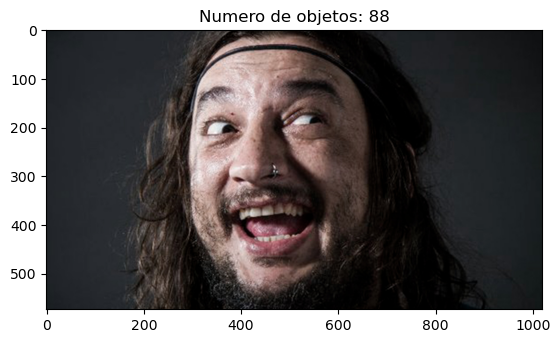

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,binary=cv2.threshold(gray,127,255,cv2.THRESH_BINARY)
    e_img=measure.label(binary,connectivity=2)
    num_obj=np.max(e_img)
    return num_obj

imagen=cv2.imread('bananero.jpg')
conteo=contar_elementos(imagen)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title(f'Numero de objetos: {conteo}')
plt.show()

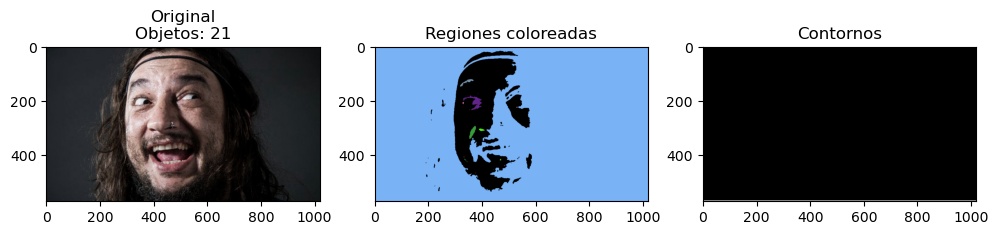

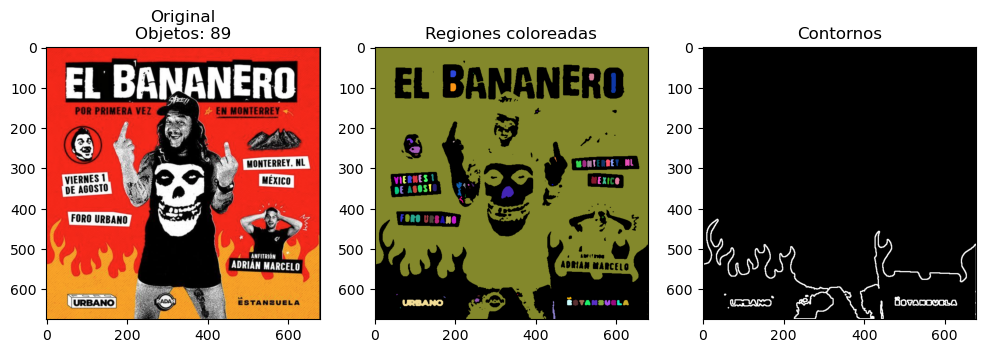

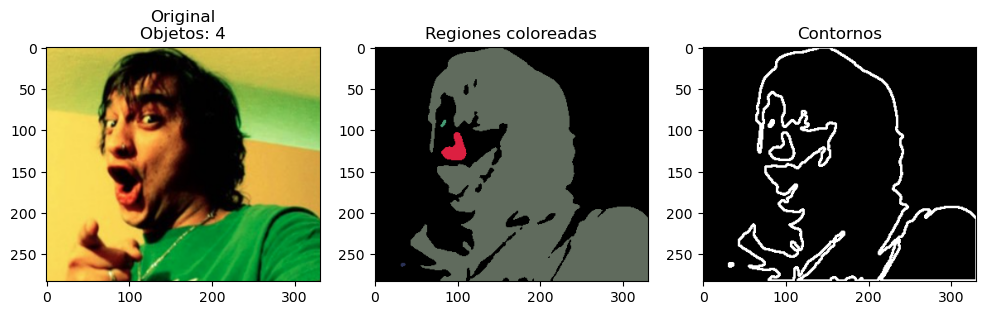

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def procesar_imagen(ruta):
    img = cv2.imread(ruta)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    num_labels, labels = cv2.connectedComponents(binary)

    colores = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
    colores[0] = [0, 0, 0]  # fondo negro
    imagen_coloreada = colores[labels]

    contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contorno_img = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

    num_objetos = num_labels - 1

    return img, imagen_coloreada, contorno_img, num_objetos

imagenes = ['bananero.jpg', 'bananero2.png', 'bananero3.png']

for ruta in imagenes:
    original, coloreada, contornos, cantidad = procesar_imagen(ruta)

    plt.figure(figsize=(12,4))

    plt.subplot(131)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title(f'Original\nObjetos: {cantidad}')

    plt.subplot(132)
    plt.imshow(coloreada)
    plt.title('Regiones coloreadas')

    plt.subplot(133)
    plt.imshow(contornos, cmap='gray')
    plt.title('Contornos')

    plt.show()